# Dia 2 — Visualização de Dados com Matplotlib e Seaborn

## Sobre o dataset
**Diamonds** é um dataset clássico com 53.940 diamantes reais contendo informações de:
- **carat** — peso em quilates
- **cut** — qualidade do corte (Fair, Good, Very Good, Premium, Ideal)
- **color** — cor (D = melhor, J = pior)
- **clarity** — claridade (IF = melhor, I1 = pior)
- **depth / table** — proporções geométricas do corte
- **price** — preço em dólares
- **x, y, z** — dimensões físicas em mm

In [1]:
# Dia 2 — Visualização de Dados com Matplotlib e Seaborn
# Dataset: Diamantes (55.940 diamantes reais com preço, quilate, corte, cor e claridade)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Carregar o dataset direto do seaborn
df = sns.load_dataset('diamonds')

# Primeira espiada nos dados
print("Shape:", df.shape)
print("\nColunas:", df.columns.to_list())
print("\nPrimeiras Linhas:")
df.head()

Shape: (53940, 10)

Colunas: ['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y', 'z']

Primeiras Linhas:


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


## Gráfico 2 — Preço médio por qualidade do corte

O corte é um dos principais fatores de valorização de um diamante.
A escala vai de **Fair** (mais básico) até **Ideal** (mais refinado).

**Pergunta:** diamantes com corte melhor são necessariamente mais caros?

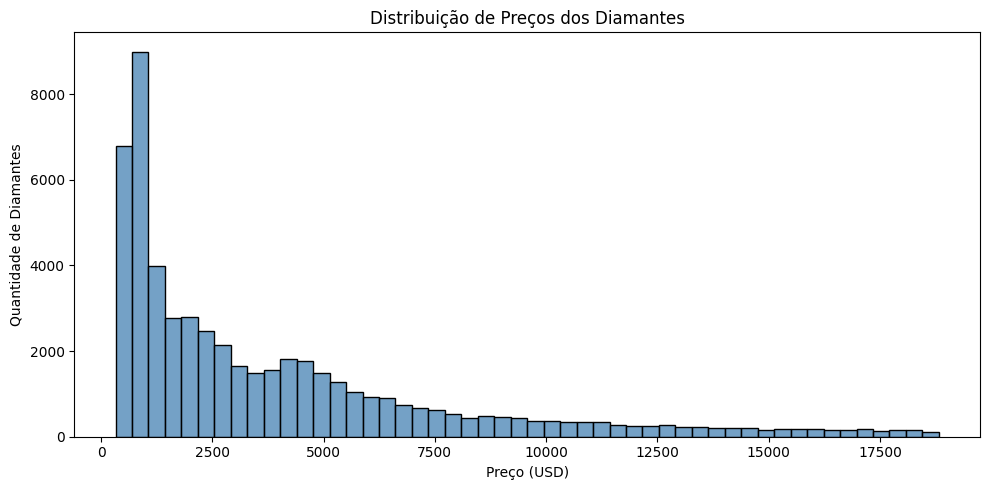

In [2]:
# --- Gráfico 1: Distribuição de preços ---
# Pergunta: como os preços estão distribuídos? Tem muitos baratos ou caros?

plt.figure(figsize=(10, 5))
sns.histplot(df['price'], bins=50, color='steelblue')
plt.title('Distribuição de Preços dos Diamantes')
plt.xlabel('Preço (USD)')
plt.ylabel('Quantidade de Diamantes')
plt.tight_layout()
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

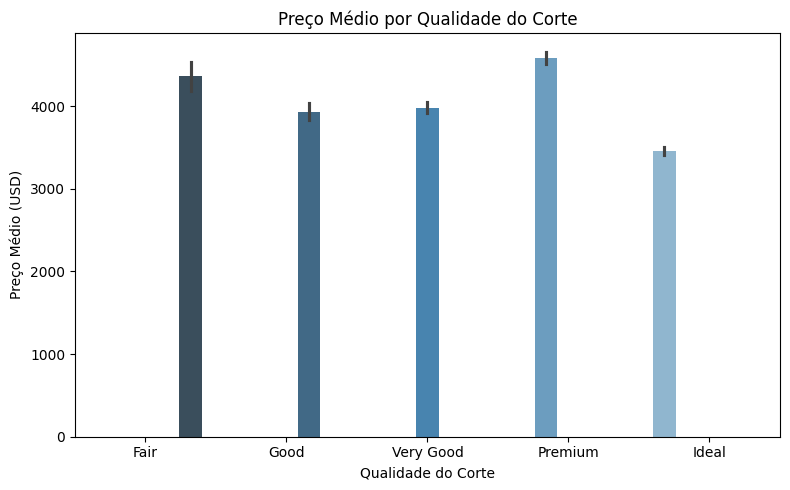

In [4]:
# --- Gráfico 2: Preço médio por qualidade do corte ---
# Pergunta: diamantes com corte Ideal são os mais caros?

plt.figure(figsize=(8, 5))
ordem = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
sns.barplot(data=df, x='cut', y='price', order=ordem,
            hue='cut', palette='Blues_d', legend=False)
plt.title('Preço Médio por Qualidade do Corte')
plt.xlabel('Qualidade do Corte')
plt.ylabel('Preço Médio (USD)')
plt.tight_layout()
plt.show

### Conclusão — Gráfico 2

Surpreendentemente, diamantes com corte **Ideal** não são os mais caros na média.
O corte **Premium** lidera, e o **Fair** vem em segundo lugar.

Hipótese: diamantes de corte inferior tendem a ser maiores (mais quilates),
o que eleva o preço médio. O quilate pode estar "mascarando" o efeito do corte.

Vamos investigar isso no próximo gráfico.

## Gráfico 3 — Relação entre quilate e preço (dispersão)

Quilate é o peso do diamante — quanto maior, mais raro e mais caro.
Mas será que essa relação é linear? Ou o preço cresce de forma exponencial?

Um gráfico de dispersão (*scatter plot*) mostra cada diamante como um ponto,
revelando o padrão geral entre duas variáveis numéricas.

**Pergunta:** quanto maior o quilate, maior o preço?

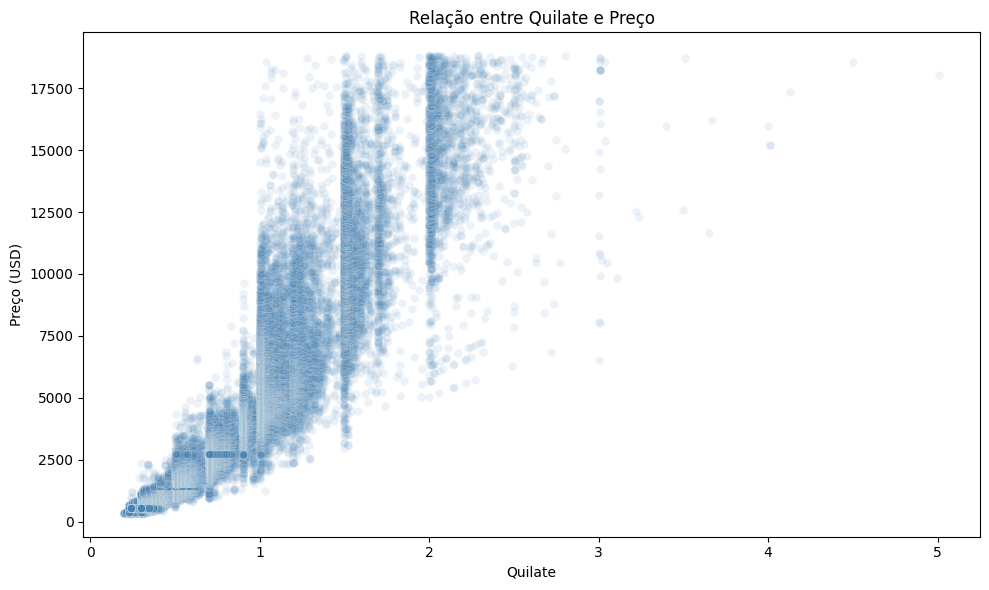

In [5]:
# --- Gráfico 3: Relação entre quilate e preço ---

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='carat', y='price', alpha=0.1, color='steelblue')
plt.title('Relação entre Quilate e Preço')
plt.xlabel('Quilate')
plt.ylabel('Preço (USD)')
plt.tight_layout()
plt.show()

### Conclusão — Gráfico 3

A relação entre quilate e preço é clara: **quanto maior o quilate, maior o preço**.
Porém o crescimento não é linear — ele acelera nos quilates mais altos,
sugerindo uma relação exponencial ou de potência.

Também é possível ver "degraus" verticais de pontos concentrados em
0.5, 1.0, 1.5 e 2.0 quilates — pesos psicológicos de mercado,
onde a demanda e o preço saltam.

## Gráfico 4 — Distribuição da claridade (gráfico de barras)

A claridade mede a ausência de imperfeições internas do diamante.
A escala vai de **I1** (mais inclusões) até **IF** (internamente perfeito).

**Pergunta:** qual o nível de claridade mais comum no mercado?

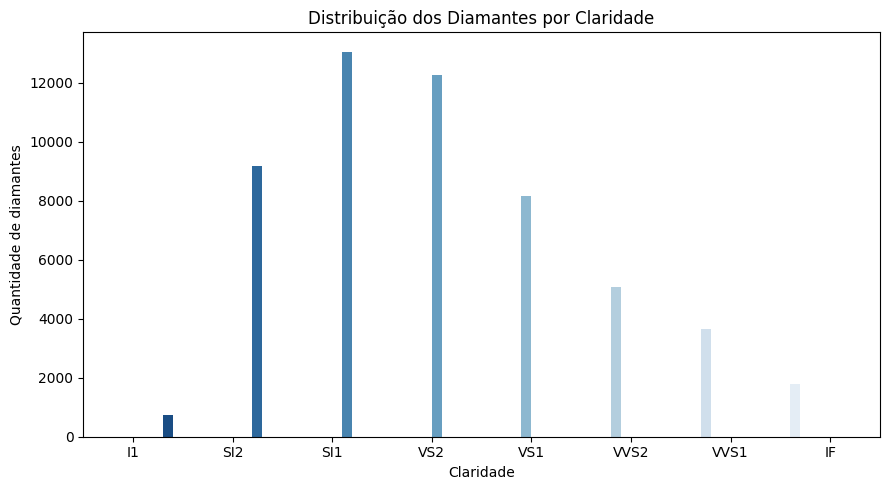

In [6]:
# --- Gráfico 4: Distribuição por claridade ---

plt.figure(figsize=(9, 5))
ordem_claridade = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']
sns.countplot(data=df, x='clarity', order=ordem_claridade, 
            hue='clarity', palette='Blues', legend=False)
plt.title('Distribuição dos Diamantes por Claridade')
plt.xlabel('Claridade')
plt.ylabel('Quantidade de diamantes')
plt.tight_layout()
plt.show()

### Conclusão — Gráfico 4

O nível de claridade mais comum é **SI1** e **VS2** — categorias intermediárias.
Diamantes perfeitos (**IF**) e com muitas inclusões (**I1**) são os mais raros no dataset.

Isso reflete o mercado real: a maior parte das joias comerciais usa pedras
de claridade média, equilibrando qualidade e custo.

## Gráfico 5 — Heatmap de correlação

Um heatmap mostra a **força da relação entre variáveis numéricas**.
Quanto mais escura a célula, mais forte a correlação (positiva ou negativa).

**Pergunta:** quais variáveis têm mais influência sobre o preço?

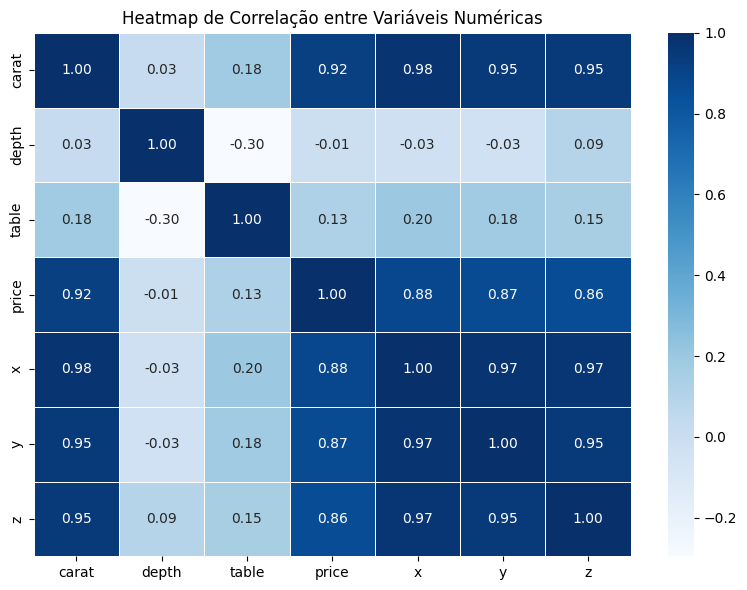

In [7]:
# --- Gráfico 5: Heatmap de correlação ---

plt.figure(figsize=(8, 6))
colunas_numericas = df[['carat', 'depth', 'table', 'price', 'x', 'y', 'z']]
correlacao = colunas_numericas.corr()

sns.heatmap(correlacao, annot=True, fmt='.2f', cmap='Blues',
            linewidths=0.5)
plt.title('Heatmap de Correlação entre Variáveis Numéricas')
plt.tight_layout()
plt.show()

### Conclusão — Gráfico 5

As variáveis com maior correlação com o **preço** são:
- **carat** (0.92) — correlação fortíssima, confirma o Gráfico 3
- **x, y, z** (≈0.88) — as dimensões físicas seguem o quilate de perto

**depth** e **table** têm correlação fraca com o preço — são proporções do corte,
não do tamanho da pedra.

Isso orienta qualquer modelo preditivo: **quilate e dimensões são as features mais importantes**.

## Gráfico 6 — Preço médio por cor

A cor do diamante é classificada de **D** (incolor, mais raro) até **J** (levemente amarelado).
Diamantes incolores são considerados mais valiosos pela gemologia clássica.

**Pergunta:** a cor D é realmente a mais cara na prática do mercado?

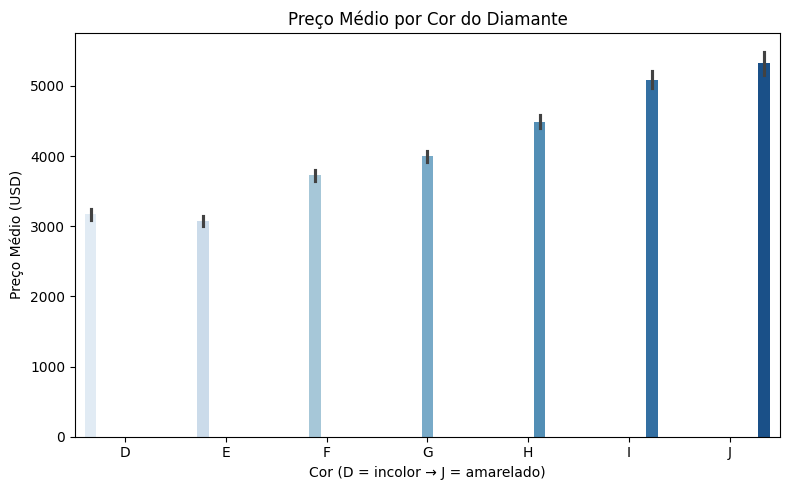

In [8]:
# --- Gráfico 6: Preço médio por cor ---

plt.figure(figsize=(8, 5))
ordem_cor = ['D', 'E', 'F', 'G', 'H', 'I', 'J']
sns.barplot(data=df, x='color', y='price', order=ordem_cor,
            hue='color', palette='Blues', legend=False)
plt.title('Preço Médio por Cor do Diamante')
plt.xlabel('Cor (D = incolor → J = amarelado)')
plt.ylabel('Preço Médio (USD)')
plt.tight_layout()
plt.show()

### Conclusão — Gráfico 6

Mais uma surpresa: diamantes cor **J** (amarelados) têm preço médio **maior**
do que os incolores **D**.

A explicação é a mesma do Gráfico 2: o quilate é uma variável de confusão.
Diamantes de cor inferior tendem a ser maiores, elevando o preço médio.

Isso reforça que análises univariadas (uma variável por vez) podem enganar.
Modelos de Machine Learning consideram todas as variáveis simultaneamente —
e por isso são mais precisos.

## Encerramento — Dia 2

Hoje criamos 6 visualizações com matplotlib e seaborn, explorando
o dataset de diamantes sob diferentes ângulos.

**Principais aprendizados:**
- Histograma revela a distribuição de uma variável
- Gráfico de barras compara médias entre categorias
- Scatter plot mostra relação entre duas variáveis numéricas
- Heatmap revela correlações entre todas as variáveis de uma vez
- Variáveis de confusão podem inverter conclusões intuitivas
- O quilate é o principal determinante do preço de um diamante

**Próximo passo — Dia 3:** limpeza e preparação de dados.